#### **STEP3** 基于DMRG计算线性氢链H_n的基态能量和键级

代码撰写：李思绎 王江腾

In [18]:
import numpy as np
from pyscf import gto, scf, lo
from pyblock2._pyscf.ao2mo import integrals as itg
from pyblock2.driver.core import DMRGDriver, SymmetryTypes

#### **1. block2的基本用法**

DMRG计算的基本流程
   - 定义系统（PySCF/mol）
   - 初始化Driver（对称性/轨道/电子）
   - 构建MPO（哈密顿量）
   - DMRG扫荡（优化MPS）

##### **1.1** 初始化DMRG driver

```python
from pyblock2.driver.core import DMRGDriver, SymmetryTypes

driver = DMRGDriver(
    scratch="./tmp",              # 临时文件目录（存放 MPS 中间数据）
    symm_type=SymmetryTypes.SU2,  # 对称性类型
    n_threads=4                   # 并行线程数
)
```

##### **1.2** 初始化系统信息

```python
driver.initialize_system(
    n_sites=ncas,     # 轨道数（MPS 的格点数）
    n_elec=n_elec,    # 电子数
    spin=spin,        # 自旋（2S，单重态=0，三重态=2）
)
```

##### **1.3** 构建MPO
```python
mpo = driver.get_qc_mpo(
    h1e=h1e,     # 单电子积分（动能+核吸引）
    g2e=g2e,     # 双电子积分（电子排斥，化学符号 (ij|kl)）
    ecore=ecore, # 核排斥能常数
    iprint=1     # 打印 MPO 信息
)
```

##### **1.4** 设置初始MPS

```python
ket = driver.get_random_mps(
    tag="GS",       # MPS 标签
    bond_dim=250,   # 初始键维度
    nroots=1        # 求解态的数量（1=只求基态）
)
```

##### **1.5** DMRG扫荡

```python
energy = driver.dmrg(
    mpo,          # 哈密顿量 MPO
    ket,          # 初始 MPS
    n_sweeps=20,  # 最大扫荡次数
    bond_dims=[250]*4 + [500]*4,  # 每次扫荡的 bond_dim
    noises=[1e-4]*4 + [1e-5]*4 + [0],  # 每次扫荡的噪声
    thrds=[1e-10]*8,  # 每次扫荡的 Lanczos 收敛阈值
    iprint=1       # 打印级别
)
```

_扫荡参数的选择_
  
- 扫荡 0-3： bond_dim=250, noise=1e-4  ← 低精度快速逼近
- 扫荡 4-7： bond_dim=500, noise=1e-5  ← 提高精度，噪声衰减
- 扫荡 8+ ： bond_dim=500, noise=0     ← 最终精确收敛

##### **1.6** 后续计算/结果输出

#### **2. 单个氢分子基态（$H_2$）**

##### **2.1** 分子结构与分子轨道建构

（PySCF）建立分子结构：  
- ```atom="H 0 0 0; H 0 0 0.74"``` 2和H原子位于同一条直线，一个位于原点，另一个相距0.74A处（符合化学中H2分子平均键长的观测结果）
- ```basis="ato3g"``` 使用STO-3G最小基组（每个原子3个高斯函数拟合1个轨道）
- ```symmetry="d2h""``` 对称性

RHF（Restricted Hartree-Fock）平均近似场计算初始分子轨道：
- ```conv_tol=1e-12``` 控制收敛精度
- ```mf = scf.RHF(mol).run()``` 简化模型，认为电子a的势场只取决于原子核的吸引和电子b的平均分布产生的库仑势。（给DMRG提供一个初始的分子轨道，DMRG会进一步修正）

In [48]:
mol = gto.M(atom="H 0 0 0; H 0 0 0.74", basis="sto3g", symmetry="d2h", verbose=0)
mf = scf.RHF(mol).run(conv_tol=1e-12)

##### **2.2** 设置哈密顿量

$H_2$的哈密顿量：
$$
H = -\frac{1}{2}\nabla_1^2 - \frac{1}{2}\nabla_2^2 - \frac{1}{|\mathbf{r}_1-\mathbf{R}_a|} - \frac{1}{|\mathbf{r}_1-\mathbf{R}_b|} - \frac{1}{|\mathbf{r}_2-\mathbf{R}_a|} - \frac{1}{|\mathbf{r}_2-\mathbf{R}_b|} + \frac{1}{|\mathbf{r}_1-\mathbf{r}_2|} + \frac{1}{|\mathbf{R}_a-\mathbf{R}_b|}
$$  
这是个连续空间的微分方程，无法被DMRG直接处理；需要把H投影到RHF计算出来的分子轨道上
   - 单电子积分h1e：
$$
h_{pq} = \int \psi_p^*(\mathbf{r}) \left[ -\frac{1}{2}\nabla^2 - \frac{1}{|\mathbf{r}-\mathbf{R}_a|} - \frac{1}{|\mathbf{r}-\mathbf{R}_b|} \right] \psi_q(\mathbf{r}) \, d\mathbf{r}
$$
   - 双电子积分g2e：
$$
g_{pqrs} = \iint \psi_p^*(\mathbf{r}_1) \psi_q(\mathbf{r}_1) \, \frac{1}{|\mathbf{r}_1-\mathbf{r}_2|} \, \psi_r^*(\mathbf{r}_2) \psi_s(\mathbf{r}_2) \, d\mathbf{r}_1 d\mathbf{r}_2
$$
最后利用这些算符把哈密顿量写成离散形式，这个过程就是哈密顿量的**二次量子化**：
$$
\hat{H} = \sum_{pq} h_{pq} \, \hat{a}_p^\dagger \hat{a}_q + \frac{1}{2} \sum_{pqrs} g_{pqrs} \, \hat{a}_p^\dagger \hat{a}_r^\dagger \hat{a}_s \hat{a}_q + E_{\text{core}}
$$

In [49]:
ncas, n_elec, spin, ecore, h1e, g2e, orb_sym = itg.get_rhf_integrals(mf, ncore=0, ncas=None, g2e_symm=8)

In [50]:
#调试参数临时输出：
print(f"1. 轨道数 (ncas): {ncas}")
print(f"2. 电子数 (n_elec): {n_elec}")
print(f"3. 总自旋 (spin): {spin}")
print(f"4. 核排斥能+核心能量 (ecore): {ecore:.10f} Hartree")

1. 轨道数 (ncas): 2
2. 电子数 (n_elec): 2
3. 总自旋 (spin): 0
4. 核排斥能+核心能量 (ecore): 0.7151043391 Hartree


##### **2.3** DMRG求解

（block2）初始化DMRG：  
- ```symm_type=SymmetryTypes.SU2``` 使用SU(2)自旋对称性
- ```n_threads=4"``` 使用4线程并行计算
- ```n_sites=ncas, n_elec=n_elec, spin=spin, orb_sym=orb_sym"``` 输入轨道数、电子数、总自旋，轨道对称性（计算加速）

构建矩阵乘积算符（MPO）：
- ```mpo=driver.get_qc_mpo()``` 根据RHF的计算结果，分别给出单电子积分h1e、双电子积分g2e、核排斥能ecore和轨道对称性

生成随机MPS波函数：
- ```ket=driver.get_random_mps()``` 用一个随机的矩阵乘积态mps作为扫荡的开始
- ```tag="GS"``` 标记为基态

In [51]:
driver = DMRGDriver(scratch="./tmp", symm_type=SymmetryTypes.SU2, n_threads=4)
driver.initialize_system(n_sites=ncas, n_elec=n_elec, spin=spin, orb_sym=orb_sym)
mpo = driver.get_qc_mpo(h1e=h1e, g2e=g2e, ecore=ecore, iprint=0)
ket = driver.get_random_mps(tag="GS", bond_dim=20, nroots=1)

设定扫描参数；添加噪声防止陷入局部极小值而得不到全局最小值

In [52]:
n_sweeps = 8
bond_dims = [100] * n_sweeps          # H2 体系 bond_dim=2 即数学精确，100 绝对安全
noises    = [1e-4, 1e-5, 1e-6, 1e-7, 0, 0, 0, 0]
thrds     = [1e-10] * n_sweeps

DMRG计算
- 此处手动修改```iprint=1```可显示每次扫荡输出

In [53]:
energy_DMRG = driver.dmrg(mpo, ket, n_sweeps=n_sweeps,
                     bond_dims=bond_dims, noises=noises, thrds=thrds, iprint=0)
print(f"H2 基态能量 = {energy_DMRG:.12f} Hartree")

H2 基态能量 = -1.137283834489 Hartree


##### **2.4** 计算结果分析

把我们计算的结果-1.137Hartree和PySCF内置的fci计算结果做对比，发现结果一致。证明我们DMRG扫荡计算结果的正确性。 

In [54]:
# 3. 对照验证：PySCF 内置 FCI 精确值
from pyscf import fci
fci_e = fci.direct_spin1.kernel(h1e, g2e, ncas, n_elec)[0] + ecore
print(f"PySCF内置的FCI参考值：   {fci_e:.12f} Hartree")
print(f"与DMRG计算结果的误差：   {energy_DMRG - fci_e:.2e} Hartree")

PySCF内置的FCI参考值：   -1.137283834489 Hartree
与DMRG计算结果的误差：   -8.88e-16 Hartree


但通过查询，我们发现$H_2$基态能量值约为-1.1745 Hartree，与我们的计算结果-1.137 Hartree有显著差异。这个误差的主要来源是由于**基组的选择**：我们选择的是STO-3G极小基组。

鉴于$H_2$分子的计算规模本身也较小，我们这里尝试换用基组```cc-pVTZ```，它加入了极化函数，让波函数的试探空间变大，从而更容易找到能量更低的解。

In [55]:
mol = gto.M(atom="H 0 0 0; H 0 0 0.74", basis="cc-pVTZ", symmetry=True, verbose=0)
mf = scf.RHF(mol).run(conv_tol=1E-14)
ncas, n_elec, spin, ecore, h1e, g2e, orb_sym = itg.get_rhf_integrals(mf, ncore=0, ncas=10, g2e_symm=8)

driver = DMRGDriver(scratch="./tmp", symm_type=SymmetryTypes.SU2, n_threads=4)
driver.initialize_system(n_sites=ncas, n_elec=n_elec, spin=spin, orb_sym=orb_sym)
mpo = driver.get_qc_mpo(h1e=h1e, g2e=g2e, ecore=ecore, iprint=0)
ket = driver.get_random_mps(tag="GS", bond_dim=20, nroots=1)

n_sweeps = 8
bond_dims = [100] * n_sweeps          # H2 体系 bond_dim=2 即数学精确，100 绝对安全
noises    = [1e-4, 1e-5, 1e-6, 1e-7, 0, 0, 0, 0]
thrds     = [1e-10] * n_sweeps

energy = driver.dmrg(mpo, ket, n_sweeps=n_sweeps,
                     bond_dims=bond_dims, noises=noises, thrds=thrds, iprint=0)
print(f"H2 基态能量(in cc-pVTZ) = {energy:.12f} Hartree")

H2 基态能量(in cc-pVTZ) = -1.156572416512 Hartree


这个结果相比-1.137Hartree更低了，更加接近CBS极限。

此外，观察STO-3G基组下每次Sweep的结果输出：

```python
Time elapsed =      0.047 | E =      -1.1372838345 | DE = -8.88e-16 | DW = 0.00000e+00

Sweep =    2 | Direction =  forward | Bond dimension =  100 | Noise =  1.00e-06 | Dav threshold =  1.00e-10
Time elapsed =      0.062 | E =      -1.1372838345 | DE = 4.44e-16 | DW = 0.00000e+00

Sweep =    3 | Direction = backward | Bond dimension =  100 | Noise =  1.00e-07 | Dav threshold =  1.00e-10
Time elapsed =      0.076 | E =      -1.1372838345 | DE = -4.44e-16 | DW = 0.00000e+00

Sweep =    4 | Direction =  forward | Bond dimension =  100 | Noise =  0.00e+00 | Dav threshold =  1.00e-10
Time elapsed =      0.093 | E =      -1.1372838345 | DE = 2.22e-16 | DW = 0.00000e+00
```

发现第一步扫描其实就达到了精确结果，```DW=0```是因为我们的dim设置的很大，而该问题纠缠又极小，截断误差根本没发挥作用。看来求$H_2$的问题对它来说还是太基础了hhh

#### **3. 一维氢链的计算（$H_n$）**

##### **3.1** 等间距氢链能否稳定存在？

------- 

##### **3.2** $H_n$成链的化学稳态结构

根据上述分析我们发现，对于n较大的问题，分子等间距排布所形成的结构并不稳定。查询化学领域的研究，我们了解到原子之间存在peierls二聚化效应，原子更愿意两两凑近一些。因此我们推测如果存在稳定的一维氢链，各个原子间距也应该不是等距的，而是能明显观察到两两凑近的现象。对此我们以```n=10```的情况为例，基于DMRG进一步计算。

##### 3.2.1 Peierls二聚化效应

考虑一个等间距的一维原子链，每个原子上有一个电子（半填充），能带结构是半满的。最低的一半能级被电子填满，费米能级恰好穿过能带的正中间。按照能带理论，体系有零能隙——这是金属。

但Peierls发现：如果把原子稍微推动一下，让它们两两靠近，形成"短键-长键"交替的结构。这时晶格周期从 $a$ 变成 $2a$，在费米波矢 $k_F = \pi/2a$ 处打开一个能隙。

二聚化是否发生，取决于两种能量的博弈：

|   | 对能量的影响 | 随二聚化位移 $\delta$ 的变化 |
|----|-------------|---------------------------|
| **电子能** $E_{\text{电子}}$ | 能隙打开，占据态能量降低 | $\propto -\delta^2 \ln(1/\delta)$ |
| **弹性能** $E_{\text{弹性}}$ | 偏离平衡键长，晶格形变代价 | $\propto +\delta^2$ |

总能量变化：
$$\Delta E(\delta) = \underbrace{A \delta^2}_{\text{弹性惩罚}} - \underbrace{B \delta^2 \ln\frac{1}{\delta}}_{\text{电子收益}}$$

当 $\delta$ 很小时，$\ln(1/\delta)$ 很大，电子收益**总是大于**弹性惩罚 → $\Delta E < 0$ → 故**任何一维半满金属在零温时必然二聚化**

通过我们的计算，如果最终发现$H_10$中二聚化确实发生，则说明一维氢链在热力学极限下是 Peierls 绝缘体，而非金属。

##### 3.2.2 构建二聚化坐标

在**二聚化结构**下原子按短键-长键交替排列
```
H₁ - H₂ —— H₃ - H₄ —— ...
```
对于偶数的 n，最后一对由短键连接。

依次给出原子坐标：
- ```n_atoms``` 原子个数
- ```R_short``` 短键长度
- ```R_long``` 长键长度

In [27]:
def build_dimerized_coords(n_atoms, R_short, R_long):
    coords = []
    x = 0.0
    for i in range(n_atoms):
        coords.append(['H', (x, 0, 0)])
        if i % 2 == 0:
            x += R_short
        else:
            x += R_long
    return coords

##### 3.2.3 构建DMRG能量计算

- ```basis='sto6g'``` 此处基组选择STO-6G

In [35]:
def compute_dimerized_energy(R_short, R_long, n_atoms=10, basis='sto6g', 
                             bond_dims=None, verbose=0):
    
    coords = build_dimerized_coords(n_atoms, R_short, R_long)

    mol = gto.M(atom=coords, basis=basis, symmetry='c1', verbose=verbose)
    mf = scf.RHF(mol).run(conv_tol=1e-12)

    ret = itg.get_rhf_integrals(mf, ncore=0, ncas=None, g2e_symm=8)
    nso, nmo, ncore_out, ecore, h1e, g2e_compressed, orb_sym = ret
    
    from pyscf import ao2mo
    ncas = mf.mo_coeff.shape[1]
    g2e = ao2mo.restore(8, g2e_compressed, ncas)
    
    driver = DMRGDriver(scratch="./tmp_hchain", symm_type=SymmetryTypes.SU2, 
                        n_threads=4)
    driver.initialize_system(n_sites=ncas, n_elec=n_atoms, spin=0, orb_sym=orb_sym)
    mpo = driver.get_qc_mpo(h1e=h1e, g2e=g2e, ecore=ecore, integral_cutoff=1e-12)
    
    if bond_dims is None:
        bond_dims = [50] * 4 + [100] * 4
    n_sweeps = len(bond_dims)
    noises = [1e-4] * 4 + [1e-5] * 4 + [0] * (n_sweeps - 8)
    if len(noises) < n_sweeps:
        noises += [0] * (n_sweeps - len(noises))
    thrds = [1e-8] * n_sweeps
    
    ket = driver.get_random_mps(tag="KET", bond_dim=bond_dims[0], nroots=1)
    energy = driver.dmrg(mpo, ket, n_sweeps=n_sweeps,
                         bond_dims=bond_dims, noises=noises, thrds=thrds, iprint=verbose)
    
    return energy, mf.e_tot

##### 3.2.4 二维粗扫描，寻找最优键长分配

截至目前，我们并不知道```R_short```和```R_long```应该是多少，我们需要通过计算机枚举，找到能得到最稳定的能量时的```R_short```和```R_long```。

In [36]:
n_atoms = 10
R_short_range = np.arange(0.6, 1.3, 0.1)  # 短键：0.6 ~ 1.2 Å
R_long_range  = np.arange(0.8, 1.5, 0.1)  # 长键：0.8 ~ 1.4 Å

先用粗步长快速锁定能量最低区域。因计算量较大（约 40-50 次 DMRG），使用较小的 bond_dim、较低的收敛阈值。

In [38]:
results = []
for R_s in R_short_list:
    for R_l in R_long_list:
        if R_l <= R_s:
            continue  # 跳过无意义的组合（长键必须大于短键）
        try:
            energy, e_rhf = compute_dimerized_energy(
                R_s, R_l, n_atoms=10, basis='sto6g', verbose=0
            )
            results.append({
                'R_short': R_s, 'R_long': R_l,
                'E_DMRG': energy, 'E_RHF': e_rhf,
                'E_corr': energy - e_rhf
            })
            print(f"Rs={R_s:.1f} Å, Rl={R_l:.1f} Å → E_DMRG = {energy:.10f} Hartree")
        except Exception as e:
            print(f"Rs={R_s:.1f}, Rl={R_l:.1f} 计算出错: {e}")

integral symmetrize error =  0.0
integral cutoff error =  3.1117326858481713e-12
mpo terms =       2960

Build MPO | Nsites =    10 | Nterms =       2960 | Algorithm = FastBIP | Cutoff = 1.00e-20
 Site =     0 /    10 .. Mmpo =    13 DW = 0.00e+00 NNZ =       13 SPT = 0.0000 Tmvc = 0.001 T = 0.007
 Site =     1 /    10 .. Mmpo =    42 DW = 0.00e+00 NNZ =       89 SPT = 0.8370 Tmvc = 0.001 T = 0.011
 Site =     2 /    10 .. Mmpo =    64 DW = 0.00e+00 NNZ =      217 SPT = 0.9193 Tmvc = 0.001 T = 0.014
 Site =     3 /    10 .. Mmpo =    94 DW = 0.00e+00 NNZ =      337 SPT = 0.9440 Tmvc = 0.001 T = 0.011
 Site =     4 /    10 .. Mmpo =   132 DW = 0.00e+00 NNZ =      465 SPT = 0.9625 Tmvc = 0.001 T = 0.009
 Site =     5 /    10 .. Mmpo =    94 DW = 0.00e+00 NNZ =     1433 SPT = 0.8845 Tmvc = 0.001 T = 0.014
 Site =     6 /    10 .. Mmpo =    64 DW = 0.00e+00 NNZ =      337 SPT = 0.9440 Tmvc = 0.000 T = 0.008
 Site =     7 /    10 .. Mmpo =    42 DW = 0.00e+00 NNZ =      205 SPT = 0.9237 Tmv

寻找最优的键长方案（对比result序列中能量最低的）

In [39]:
if results:
    Rs = [r['R_short'] for r in results]
    Rl = [r['R_long'] for r in results]
    Es = [r['E_DMRG'] for r in results]
    R_avg = [(r['R_short'] + r['R_long']) / 2 for r in results]
    
    idx_min = np.argmin(Es)
    best = results[idx_min]
    
    print("H₁₀ Peierls 二聚化扫描结果 (粗精度)")
    print(f"最优短键长:   R_s* = {best['R_short']:.2f} Å")
    print(f"最优长键长:   R_l* = {best['R_long']:.2f} Å")
    print(f"平均键长:     R̄   = {(best['R_short'] + best['R_long'])/2:.2f} Å")
    print(f"最低能量:     E_dim = {best['E_DMRG']:.10f} Hartree")
    print(f"二聚化参数:   δ ≡ (R_l - R_s)/R̄ = {(best['R_long'] - best['R_short'])/((best['R_short'] + best['R_long'])/2):.3f}")


H₁₀ Peierls 二聚化扫描结果 (粗精度)
最优短键长:   R_s* = 0.70 Å
最优长键长:   R_l* = 1.40 Å
平均键长:     R̄   = 1.05 Å
最低能量:     E_dim = -5.6656960966 Hartree
二聚化参数:   δ ≡ (R_l - R_s)/R̄ = 0.667


把我们刚才扫描的各点的结果在同一幅图中呈现，结果如下：

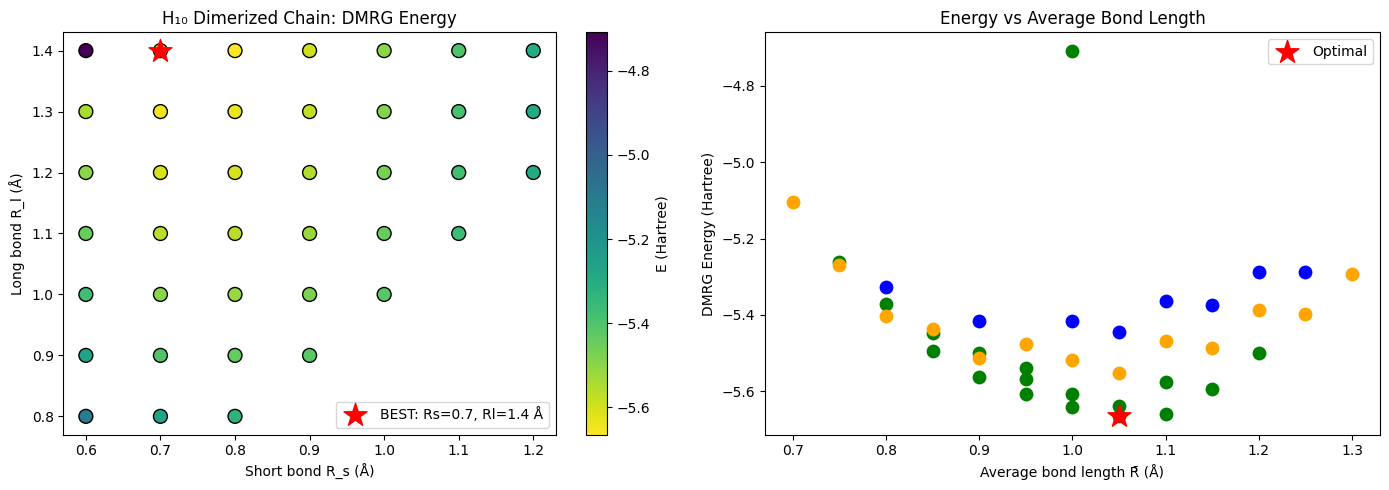

In [42]:
import matplotlib.pyplot as plt

if results:
    Rs = [r['R_short'] for r in results]
    Rl = [r['R_long'] for r in results]
    Es = [r['E_DMRG'] for r in results]
    R_avg = [(r['R_short'] + r['R_long']) / 2 for r in results]
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    sc = ax1.scatter(Rs, Rl, c=Es, cmap='viridis_r', s=100, edgecolors='k')
    ax1.scatter(best['R_short'], best['R_long'], c='red', marker='*', s=300, 
                label=f'BEST: Rs={best["R_short"]:.1f}, Rl={best["R_long"]:.1f} Å')
    ax1.set_xlabel('Short bond R_s (Å)')
    ax1.set_ylabel('Long bond R_l (Å)')
    ax1.set_title('H₁₀ Dimerized Chain: DMRG Energy')
    ax1.legend()
    plt.colorbar(sc, ax=ax1, label='E (Hartree)')
    
    for i, (rs, rl, e, ravg) in enumerate(zip(Rs, Rl, Es, R_avg)):
        delta = (rl - rs) / ravg
        if delta < 0.1:
            c = 'blue'
        elif delta < 0.3:
            c = 'orange'
        else:
            c = 'green'
        ax2.scatter(ravg, e, c=c, s=80)
    ax2.scatter((best['R_short']+best['R_long'])/2, best['E_DMRG'], 
                c='red', marker='*', s=300, label='Optimal')
    ax2.set_xlabel('Average bond length R̄ (Å)')
    ax2.set_ylabel('DMRG Energy (Hartree)')
    ax2.set_title('Energy vs Average Bond Length')
    ax2.legend()
    
    plt.tight_layout()
    plt.show()

也可以看出我们找到的BEST确实是能量最低点，对应的键长约为0.7-1.4。此时的最低能量约为-5.67 Hartree，比10个H均匀分布的能量低。

其实观察上图就能发现，上图“对角线”位置（横纵坐标相等的位置），那些点的能量不是最低的，所以【平均分布不是能量最低的选择，这证明了peierls二聚化效应的存在。

##### 3.2.5 精细化扫描：确认最佳的键长

刚才的计算中我们选择的收敛性条件较为宽松，主要是为了在允许的计算条件下，得到$(R_s^*, R_l^*)$的大致位置。

接下来我们对粗扫到的 $(R_s^*, R_l^*)$ 附近区域，用更高的 bond_dim 和更严的收敛阈值重新计算，确认最优结构的正确性。

因为精细化扫描的耗时巨大，建议先完成粗扫描，确认粗扫描完成（如遇kernal连接中断等问题，请重新运行前面的代码）后，请**手动打开```DO_HIGH_PRECISION = True```**，否则默认状态下DO_HIGH_PRECISION = False（确保第一遍运行全部的时候不会卡死在这里~）

In [ ]:
DO_HIGH_PRECISION = False

if DO_HIGH_PRECISION and results:
    best = results[idx_min]
    
    Rs_fine = np.arange(best['R_short'] - 0.1, best['R_short'] + 0.15, 0.05)
    Rl_fine = np.arange(best['R_long'] - 0.1, best['R_long'] + 0.15, 0.05)
    
    bond_dims_high = [100] * 4 + [200] * 4 + [300] * 4
    n_sweeps = len(bond_dims_high)
    
    fine_results = []
    for R_s in Rs_fine:
        for R_l in Rl_fine:
            if R_l <= R_s:
                continue
            energy, e_rhf = compute_dimerized_energy(
                R_s, R_l, n_atoms=10, basis='sto6g',
                bond_dims=bond_dims_high, verbose=0
            )
            fine_results.append({
                'R_short': R_s, 'R_long': R_l,
                'E_DMRG': energy, 'E_RHF': e_rhf
            })
            print(f"[精细] Rs={R_s:.2f}, Rl={R_l:.2f} → E = {energy:.10f}")
    
    idx_fine = np.argmin([r['E_DMRG'] for r in fine_results])
    best_fine = fine_results[idx_fine]
    print(f"\n高精度最优: Rs*={best_fine['R_short']:.2f} Å, Rl*={best_fine['R_long']:.2f} Å")
    print(f"高精度能量: E = {best_fine['E_DMRG']:.12f} Hartree")

integral symmetrize error =  0.0
integral cutoff error =  3.1334014424640587e-12
mpo terms =       2960

Build MPO | Nsites =    10 | Nterms =       2960 | Algorithm = FastBIP | Cutoff = 1.00e-20
 Site =     0 /    10 .. Mmpo =    13 DW = 0.00e+00 NNZ =       13 SPT = 0.0000 Tmvc = 0.000 T = 0.005
 Site =     1 /    10 .. Mmpo =    42 DW = 0.00e+00 NNZ =       89 SPT = 0.8370 Tmvc = 0.001 T = 0.005
 Site =     2 /    10 .. Mmpo =    64 DW = 0.00e+00 NNZ =      217 SPT = 0.9193 Tmvc = 0.001 T = 0.007
 Site =     3 /    10 .. Mmpo =    94 DW = 0.00e+00 NNZ =      337 SPT = 0.9440 Tmvc = 0.001 T = 0.009
 Site =     4 /    10 .. Mmpo =   132 DW = 0.00e+00 NNZ =      463 SPT = 0.9627 Tmvc = 0.001 T = 0.009
 Site =     5 /    10 .. Mmpo =    94 DW = 0.00e+00 NNZ =     1433 SPT = 0.8845 Tmvc = 0.001 T = 0.009
 Site =     6 /    10 .. Mmpo =    64 DW = 0.00e+00 NNZ =      337 SPT = 0.9440 Tmvc = 0.000 T = 0.007
 Site =     7 /    10 .. Mmpo =    42 DW = 0.00e+00 NNZ =      205 SPT = 0.9237 Tmv

计算结果：
```
高精度最优: Rs*=0.75 Å, Rl*=1.50 Å
高精度能量: E = -5.687967595571 Hartree
二聚化位移 δ = Rl* - Rs* = 0.75 Å
```
对比发现这组能量确实比0.7-1.4粗扫描的更低，也就是更趋于稳态。
因为真实的$H_10$结构应该形如：
```
O - O -- O - O -- O - O -- O - O -- O - O
```

##### 3.2.6 结果分析

有趣的是，我们惊喜计算得到的短键长度$0.75$与模块2.中通过查询化学实验中测得的$H_2$分子平均键长$0.74$非常接近，所以是否说明我们计算得到的$H_10$其实就是5个$H_2$独立存在呢？让我们验算

In [56]:
E_H2 = energy_DMRG  # 前文STO-3G计算值

E_H10_dimer = best_fine['E_DMRG']
E_H10_5xH2 = 5 * E_H2

print("="*60)
print("H₁₀ 二聚化结构 vs 5个独立H₂分子")
print("="*60)
print(f"5 × E_H2          = {E_H10_5xH2:.10f} Hartree")
print(f"E_H10 (二聚化最优) = {E_H10_dimer:.10f} Hartree")
print(f"差值              = {E_H10_dimer - E_H10_5xH2:.10f} Hartree")
print(f"                  = {(E_H10_dimer - E_H10_5xH2) * 27.2114:.4f} eV")
print(f"相对误差           = {abs(E_H10_dimer - E_H10_5xH2) / abs(E_H10_5xH2) * 100:.4f}%")
print("="*60)
print("结论: H₁₀二聚化的短键单元 ≈ 几乎独立的H₂分子")

H₁₀ 二聚化结构 vs 5个独立H₂分子
5 × E_H2          = -5.6864191724 Hartree
E_H10 (二聚化最优) = -5.6879675956 Hartree
差值              = -0.0015484231 Hartree
                  = -0.0421 eV
相对误差           = 0.0272%
结论: H₁₀二聚化的短键单元 ≈ 几乎独立的H₂分子


好吧，看来所谓的$H_{10}$就是5个氢气分子 >_<

说明长氢链几乎无法稳定存在，二聚化效应会使得它们直接“抱团”两两形成小分子，这严格符合量子计算下能量最低的分布。

完结撒花！！！